In [1]:
import warnings
warnings.filterwarnings('ignore')

import keras
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
import pandas as pd

# Import of keras model and hidden layers for our convolutional network
from keras.layers import Conv2D, Activation, MaxPool2D, Dense, Flatten, Dropout

import os
for dirname, _, filenames in os.walk('/content/Hand_gesture_recog./leapGestRecog'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [6]:
CATEGORIES = ["01_palm", '02_l','03_fist','04_fist_moved','05_thumb','06_index','07_ok','08_palm_moved','09_c','10_down']
IMG_SIZE = 128

data_path = "/content/Hand_gesture_recog./leapGestRecog/leapGestRecog"


In [7]:
image_data = []
for dr in os.listdir(data_path):
    for category in CATEGORIES:
        class_index = CATEGORIES.index(category)
        path = os.path.join(data_path, dr, category)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                image_data.append([cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE)), class_index])
            except Exception as e:
                pass
image_data[0]

[array([[ 5,  4,  4, ...,  4,  2,  3],
        [ 4,  3,  5, ...,  3,  3,  3],
        [ 3,  4,  4, ...,  3,  2,  2],
        ...,
        [ 5,  4,  6, ...,  3,  4,  4],
        [ 5,  5,  5, ...,  5,  3,  3],
        [ 4,  4,  5, ...,  4,  3, 15]], dtype=uint8),
 0]

In [8]:
import random
random.shuffle(image_data)

In [9]:
input_data = []
label = []
for X, y in image_data:
    input_data.append(X)
    label.append(y)

In [10]:
label[:10]

[1, 8, 5, 4, 1, 1, 1, 8, 0, 1]

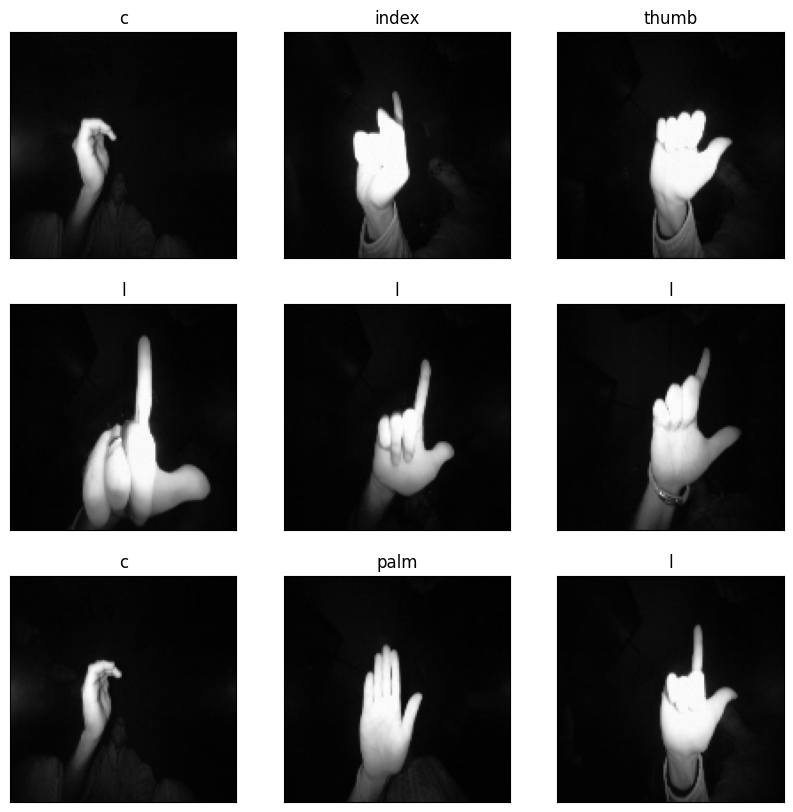

In [11]:
plt.figure(1, figsize=(10,10))
for i in range(1,10):
    plt.subplot(3,3,i)
    plt.imshow(image_data[i][0], cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(CATEGORIES[label[i]][3:])
plt.show()

In [12]:

input_data = np.array(input_data)
label = np.array(label)
input_data = input_data/255.0
input_data.shape

(20000, 128, 128)

In [13]:
import keras
from keras.utils import to_categorical
label = to_categorical(label)

In [14]:
input_data.shape = (-1, IMG_SIZE, IMG_SIZE, 1)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input_data, label,test_size=0.2, random_state=42, shuffle=True)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16000, 128, 128, 1)
(4000, 128, 128, 1)
(16000, 10)
(4000, 10)


In [18]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate= 0.001)

In [19]:
model = keras.models.Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), input_shape = (IMG_SIZE, IMG_SIZE, 1)))
model.add(Activation('relu'))


model.add(Conv2D(filters = 32, kernel_size = (3,3)))
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
             optimizer = optimizer,
             metrics = ['accuracy'])

In [20]:
history = model.fit(X_train, y_train, epochs =10, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.8476 - loss: 0.4703 - val_accuracy: 0.9980 - val_loss: 0.0095
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9981 - loss: 0.0074 - val_accuracy: 0.9908 - val_loss: 0.0358
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9982 - loss: 0.0072 - val_accuracy: 0.9890 - val_loss: 0.0256
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 1.0000 - loss: 2.9431e-05 - val_accuracy: 0.9990 - val_loss: 0.0032
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 1.0000 - loss: 2.4812e-05 - val_accuracy: 0.9992 - val_loss: 0.0018
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 1.0000 - loss: 3.0183e-06 - val_accuracy: 0.9992 - val_loss: 0.0018
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accura

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    31,490,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,507,328 (360.52 MB)

 Trainable params: 31,502,442 (120.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,004,886 (240.34 MB)

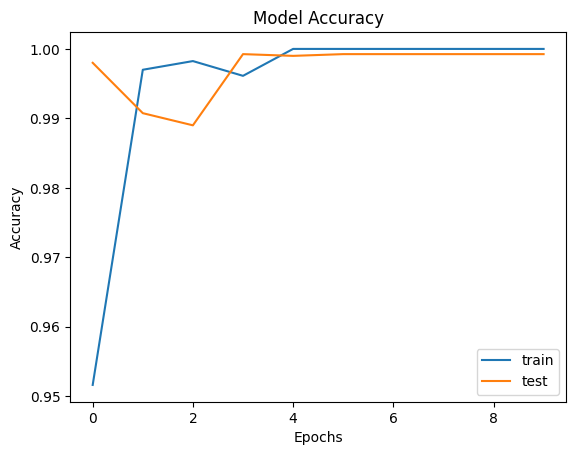

In [22]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

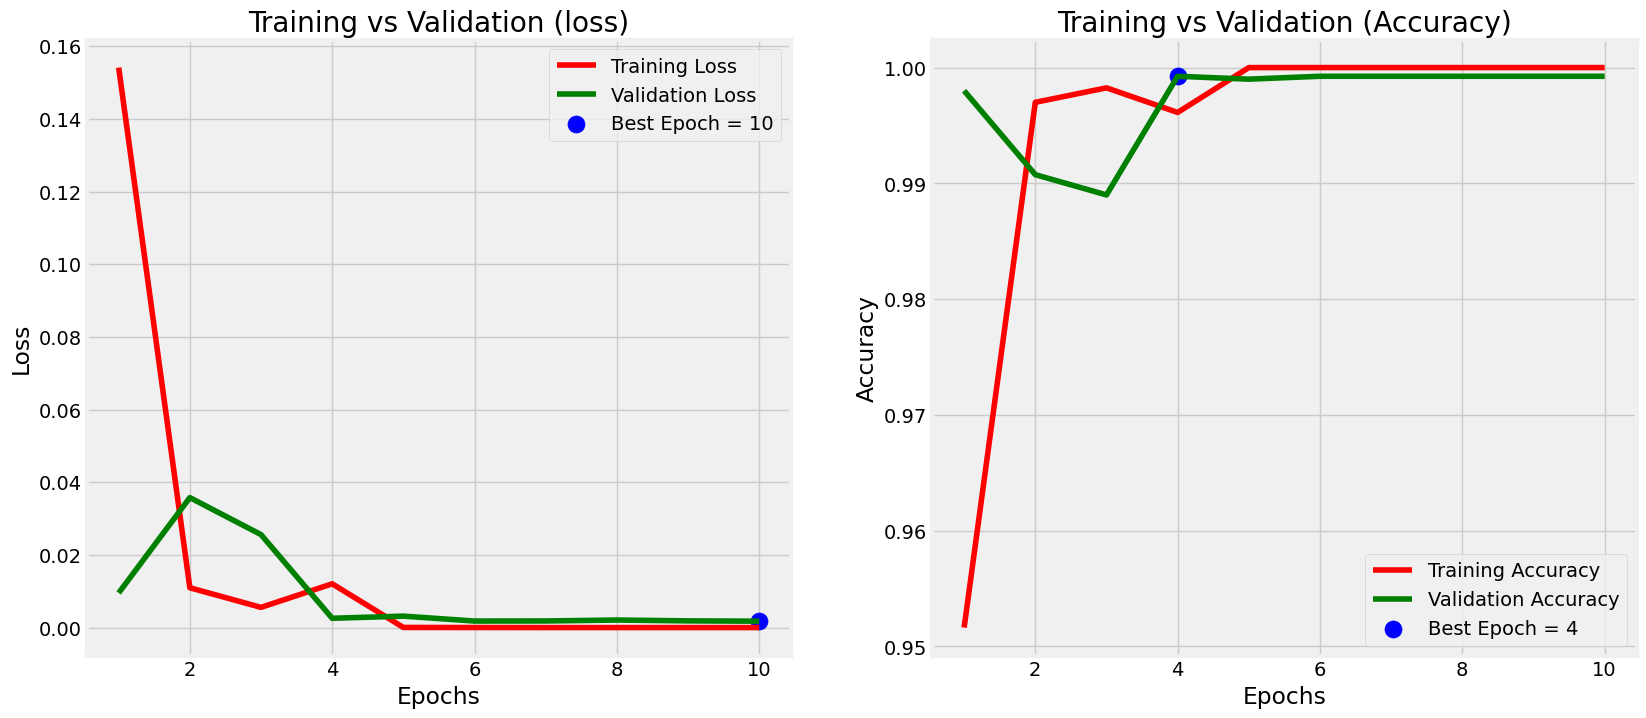

In [23]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
index_acc = np.argmax(val_acc)

val_lowest = val_loss[index_loss]
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best Epoch = {str(index_loss + 1)}'
acc_label = f'Best Epoch = {str(index_acc + 1)}'

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r', label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss +1 , val_lowest , s = 150 , c = 'blue' , label = loss_label)
plt.title('Training vs Validation (loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r', label= 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s= 150 , c = 'blue' , label= acc_label)
plt.title('Training vs Validation (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show();

In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test accuracy: {:2.2f}%'.format(test_accuracy*100))

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9993 - loss: 0.0024
Test accuracy: 99.92%


In [25]:
model.save("Hand_recog.h5")

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("Hand_recog.h5")

image_path = ''

IMG_HEIGHT = 128
IMG_WIDTH = 128


img = image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0



predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print(f"The model predicts: {predicted_class} fingers with a confidence of {confidence:.2f}")


import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} fingers (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()